# 🌐 Herramienta Interactiva de Ajuste de Perfiles de Difracción

**Basada en:** difraciones.py (Joel Castro 2019) y arranque.py

**Objetivo:** Explorar cómo varían forma, tamaño, orientación e impacto en el perfil de difracción, e identificar **degeneraciones**.

---

## 1️⃣ Importar librerías y configurar entorno

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, RadioButtons
import pandas as pd
from scipy.optimize import minimize, differential_evolution
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configurar visualización
%matplotlib widget
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2️⃣ Cargar funciones de difracción (difraciones.py)

In [26]:
# ========== LIBRERÍA DE DIFRACCIÓN ==========

def cart2pol(x, y):
    rho = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return phi, rho

def pol2cart(rho, phi):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    return x, y

def pupilCO(M, D, d):
    '''Generar obstrucción circular (apertura - obstrucción central)'''
    m = np.linspace(-D/2, D/2, M)
    a, b = np.meshgrid(m, m)
    th, r = cart2pol(a, b)
    P = np.double(r >= d/2)
    return P

def fresnel(U0, M, plano, z, lmda):
    '''Calcular patrón de difracción de Fresnel (intensidad)'''
    k = 2 * np.pi / lmda
    nx, ny = np.shape(U0)
    x = (plano / M) * nx
    y = (plano / M) * ny
    fx = 1 / x
    fy = 1 / y
    
    u = np.ones((nx, 1)) * (np.arange(0, nx) - nx/2) * fx
    v = np.transpose((np.arange(0, ny) - ny/2) * np.ones((ny, 1)) * fy)
    
    O = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(U0)))
    H = np.exp(1j*k*z) * np.exp(-1j*np.pi*(lmda*z)*(u**2 + v**2))
    
    U = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(np.multiply(O, H))))
    I = np.abs(U)**2
    return I

def extraer_perfil(I0, M, D, T, b):
    '''Extraer perfil 1D del patrón 2D de difracción'''
    m2p = M / D
    x = np.linspace(-D/2, D/2, M)
    
    x1 = x * np.cos(T*np.pi/180) - b * np.sin(T*np.pi/180)
    x2 = x * np.sin(T*np.pi/180) + b * np.cos(T*np.pi/180)
    
    hp = np.array(m2p * x1) + M/2
    vp = np.array(m2p * x2) + M/2
    hp = hp.astype(int)
    vp = vp.astype(int)
    
    # Limitar índices
    hp = np.clip(hp, 0, M-1)
    vp = np.clip(vp, 0, M-1)
    
    y = np.ones(x.shape)
    for k in range(M-1):
        y[k] = I0[vp[k], hp[k]]
    
    return x, y

def calc_plano(d, lmda, ua):
    '''Calcular tamaño óptimo del plano de difracción'''
    z = ua * 1.496e11
    fscale = np.sqrt(lmda * z / 2)
    Rho = d / (2 * fscale)
    plano = (50 * d) / Rho
    return plano

print("Funciones de difracción cargadas")

Funciones de difracción cargadas


## 3️⃣ Definir clase para ajuste (basada en arranque.py)

In [27]:
class AjustadorDifraccion:
    """Clase principal para generar y ajustar perfiles de difracción"""
    
    def __init__(self, M=512, lmda=600e-9, ua=40):
        self.M = M
        self.lmda = lmda
        self.ua = ua
        self.z = ua * 1.496e11
        self.plano = calc_plano(3000, lmda, ua)
        print(f"Ajustador inicializado: M={M}, λ={lmda*1e9:.0f}nm, ua={ua}")
        
    def elipse(self, a, b, theta=0):
        '''Crear apertura elíptica'''
        x = np.linspace(-self.plano/2, self.plano/2, self.M)
        X, Y = np.meshgrid(x, x)
        ct, st = np.cos(theta*np.pi/180), np.sin(theta*np.pi/180)
        Xr = ct*X + st*Y
        Yr = -st*X + ct*Y
        U = np.ones((self.M, self.M))
        U[(Xr/a)**2 + (Yr/b)**2 <= 1] = 0
        return U
    
    def circular(self, d):
        '''Crear apertura circular'''
        x = np.linspace(-self.plano/2, self.plano/2, self.M)
        X, Y = np.meshgrid(x, x)
        r = np.sqrt(X**2 + Y**2)
        U = np.ones((self.M, self.M))
        U[r <= d/2] = 0
        return U
    
    def cuadrado(self, d):
        '''Crear apertura cuadrada'''
        x = np.linspace(-self.plano/2, self.plano/2, self.M)
        X, Y = np.meshgrid(x, x)
        U = np.ones((self.M, self.M))
        U[(np.abs(X) <= d/2) & (np.abs(Y) <= d/2)] = 0
        return U
    
    def binario(self, d):
        '''Crear apertura binaria de contacto'''
        x = np.linspace(-self.plano/2, self.plano/2, self.M)
        X, Y = np.meshgrid(x, x)
        r = np.sqrt(X**2 + Y**2)
        r1 = (d/2) * 0.65
        r2 = np.sqrt((d/2)**2 - r1**2)
        U = np.ones((self.M, self.M))
        U[(r >= r1) & (r <= d/2)] = 0
        U[(r >= r2) & (r <= d/2)] = 0
        return U
    
    def generar_perfil(self, forma, a, b=None, theta=0, impacto=0):
        '''Generar perfil de difracción completo'''
        if b is None:
            b = a  # Si b no se especifica, asumir forma circular
        
        # Crear pupila según forma
        if forma == 'elipse':
            pupila = self.elipse(a, b, theta)
        elif forma == 'circular':
            pupila = self.circular(a)
        elif forma == 'cuadrado':
            pupila = self.cuadrado(a)
        elif forma == 'binario':
            pupila = self.binario(a)
        else:
            pupila = self.circular(a)
        
        # Calcular difracción
        I = fresnel(pupila, self.M, self.plano, self.z, self.lmda)
        
        # Extraer perfil 1D
        x, y = extraer_perfil(I, self.M, self.plano, 0, impacto)
        
        # Normalizar
        y_norm = y / np.median(y[:50])
        
        return x, y_norm
    
    def chi_cuadrada(self, observado, calculado, error=0.03):
        '''Calcular chi-cuadrada'''
        chi2 = np.sum(((observado - calculado) / error)**2)
        return chi2
    
    def r_squared(self, observado, calculado):
        '''Calcular R-cuadrado'''
        ss_res = np.sum((observado - calculado)**2)
        ss_tot = np.sum((observado - np.mean(observado))**2)
        return 1 - (ss_res / (ss_tot + 1e-10))

print(" Clase Ajustador Difraccion definida")

 Clase Ajustador Difraccion definida


## 4️⃣ Generar datos sintéticos y visualizar

Ajustador inicializado: M=512, λ=600nm, ua=40

Generando perfil de difracción...


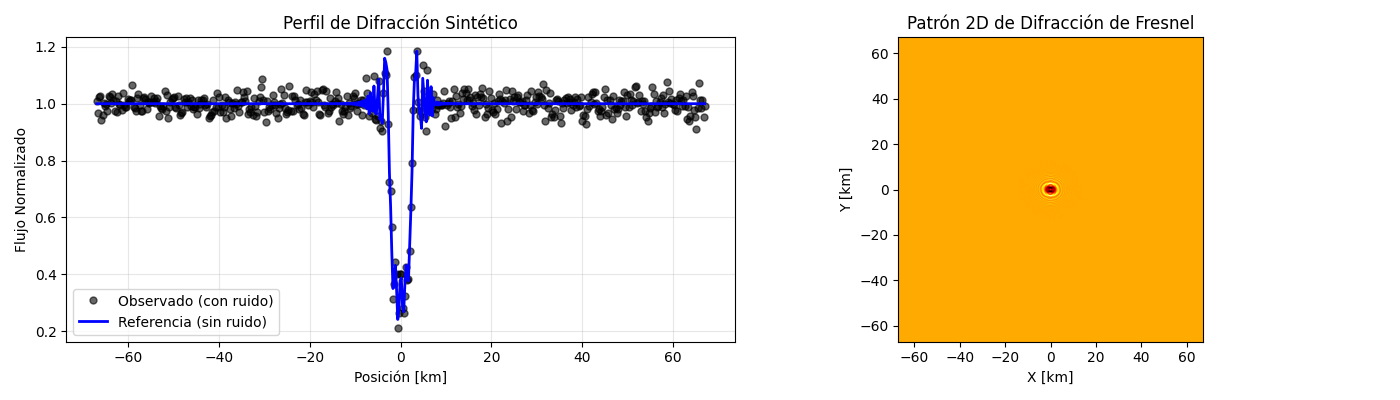

Datos sintéticos generados
   Tamaño del perfil: 512 puntos
   Rango de flujo: [0.211, 1.185]


In [28]:
# Inicializar
ajustador = AjustadorDifraccion(M=512, lmda=600e-9, ua=40)

# Generar perfil de referencia (simulando un asteroide real)
print("\nGenerando perfil de difracción...")
x_ref, y_ref = ajustador.generar_perfil('elipse', a=1800, b=1100, theta=0.5, impacto=300)

# Añadir ruido realista
rng = np.random.default_rng(42)
y_obs = y_ref + rng.normal(0, 0.03, y_ref.size)

# Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(x_ref/1000, y_obs, 'ko', label='Observado (con ruido)', markersize=5, alpha=0.6)
ax1.plot(x_ref/1000, y_ref, 'b-', label='Referencia (sin ruido)', linewidth=2)
ax1.set_xlabel('Posición [km]')
ax1.set_ylabel('Flujo Normalizado')
ax1.set_title('Perfil de Difracción Sintético')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2D del patrón de difracción
pupila = ajustador.elipse(1800, 1100, 0.5)
I_2d = fresnel(pupila, ajustador.M, ajustador.plano, ajustador.z, ajustador.lmda)
ax2.imshow(I_2d, cmap='hot', extent=[-ajustador.plano/2e3, ajustador.plano/2e3, 
                                       -ajustador.plano/2e3, ajustador.plano/2e3])
ax2.set_xlabel('X [km]')
ax2.set_ylabel('Y [km]')
ax2.set_title('Patrón 2D de Difracción de Fresnel')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Datos sintéticos generados")
print(f"   Tamaño del perfil: {len(y_obs)} puntos")
print(f"   Rango de flujo: [{y_obs.min():.3f}, {y_obs.max():.3f}]")

## 5️⃣ Interfaz Interactiva con Sliders

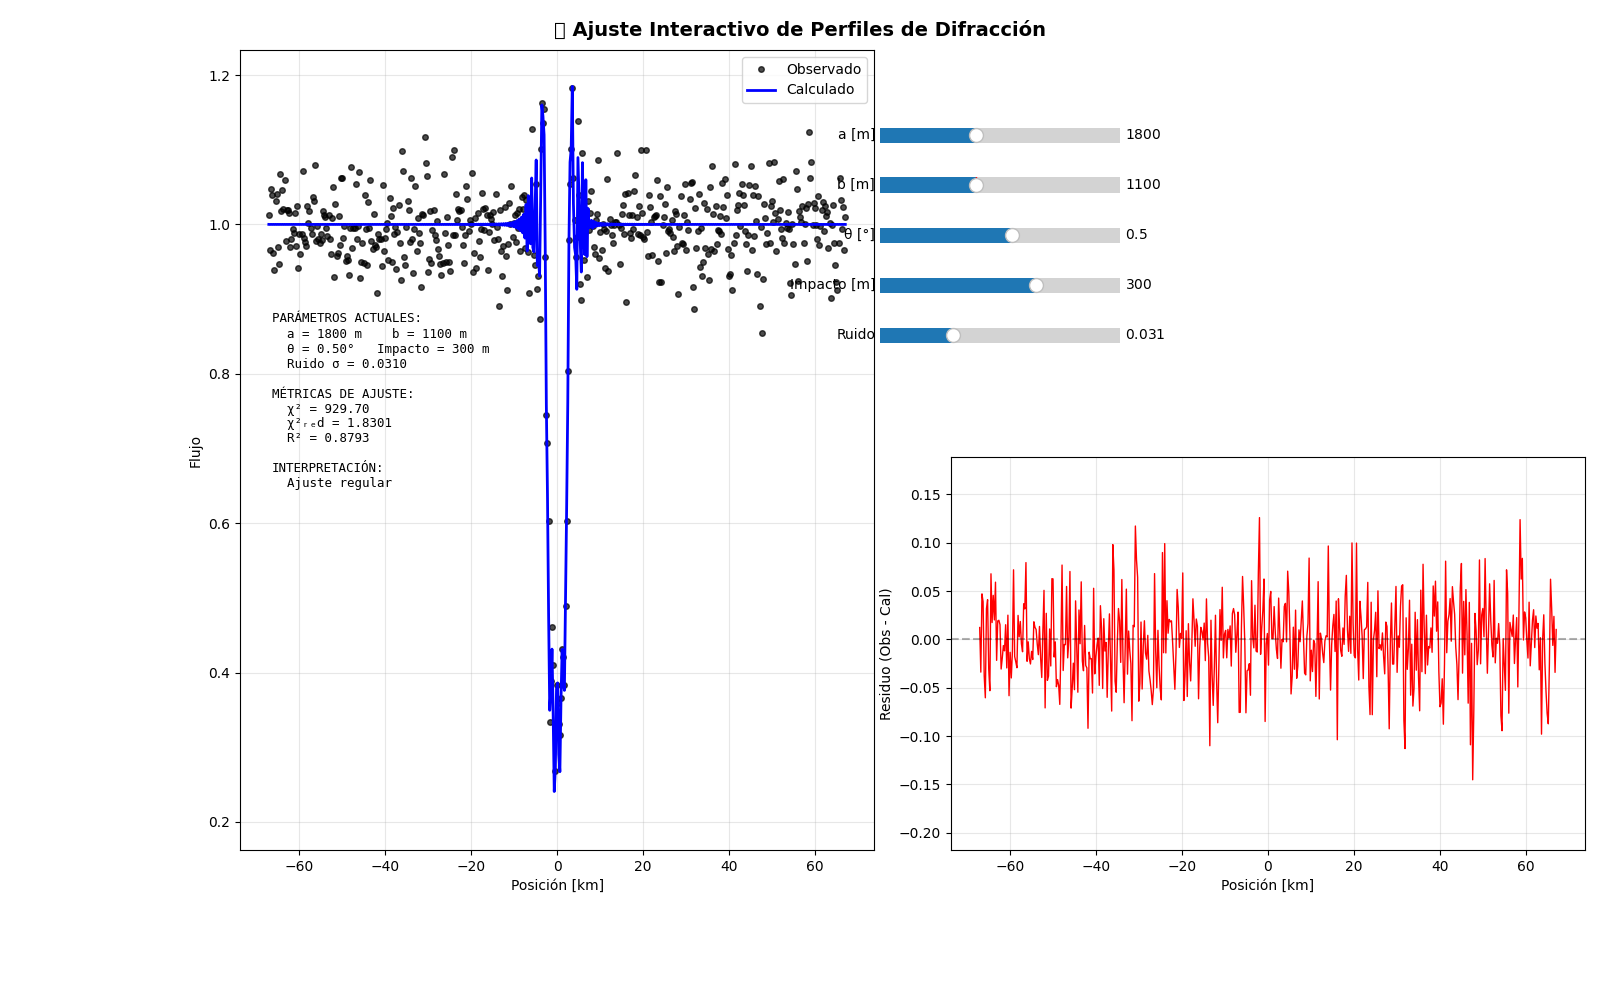

Interfaz interactiva activa


In [29]:
# Crear figura interactiva
fig = plt.figure(figsize=(16, 10))
fig.suptitle('🔬 Ajuste Interactivo de Perfiles de Difracción', fontsize=14, fontweight='bold')

# Subplots
ax_perfil = plt.subplot(2, 2, (1, 3))
ax_residual = plt.subplot(2, 2, 4)

# Inicializar líneas
line_obs, = ax_perfil.plot(x_ref/1000, y_obs, 'ko', label='Observado', markersize=4, alpha=0.7)
line_cal, = ax_perfil.plot(x_ref/1000, y_ref, 'b-', label='Calculado', linewidth=2)
ax_perfil.set_xlabel('Posición [km]')
ax_perfil.set_ylabel('Flujo')
ax_perfil.grid(True, alpha=0.3)
ax_perfil.legend()

line_res, = ax_residual.plot(x_ref/1000, np.zeros_like(y_ref), 'r-', linewidth=1)
ax_residual.set_xlabel('Posición [km]')
ax_residual.set_ylabel('Residuo (Obs - Cal)')
ax_residual.grid(True, alpha=0.3)
ax_residual.axhline(0, color='k', linestyle='--', alpha=0.3)

# Crear sliders
ax_a = plt.axes([0.55, 0.85, 0.15, 0.03])
sl_a = Slider(ax_a, 'a [m]', 1000, 3000, valinit=1800, valstep=50)

ax_b = plt.axes([0.55, 0.80, 0.15, 0.03])
sl_b = Slider(ax_b, 'b [m]', 500, 2000, valinit=1100, valstep=50)

ax_theta = plt.axes([0.55, 0.75, 0.15, 0.03])
sl_theta = Slider(ax_theta, 'θ [°]', -5, 5, valinit=0.5, valstep=0.1)

ax_impact = plt.axes([0.55, 0.70, 0.15, 0.03])
sl_impact = Slider(ax_impact, 'Impacto [m]', -1000, 1000, valinit=300, valstep=50)

ax_ruido = plt.axes([0.55, 0.65, 0.15, 0.03])
sl_ruido = Slider(ax_ruido, 'Ruido', 0.001, 0.1, valinit=0.03, valstep=0.005)

# Texto de información
ax_info = plt.axes([0.15, 0.45, 0.4, 0.25])
ax_info.axis('off')
text_info = ax_info.text(0.05, 0.95, '', fontsize=9, family='monospace',
                         transform=ax_info.transAxes, verticalalignment='top')

def actualizar(val=None):
    '''Función para actualizar gráficos en tiempo real'''
    a = sl_a.val
    b = sl_b.val
    theta = sl_theta.val
    impacto = sl_impact.val
    ruido = sl_ruido.val
    
    try:
        # Generar perfil calculado
        x_cal, y_cal = ajustador.generar_perfil('elipse', a, b, theta, impacto)
        
        # Datos observados con ruido variable
        y_obs_ruido = y_obs + rng.normal(0, ruido, y_obs.size)
        
        # Calcular métricas
        chi2 = ajustador.chi_cuadrada(y_obs_ruido, y_cal, error=ruido)
        r2 = ajustador.r_squared(y_obs_ruido, y_cal)
        dof = len(y_obs) - 4
        chi2_red = chi2 / dof if dof > 0 else chi2
        
        # Actualizar gráficos
        line_obs.set_ydata(y_obs_ruido)
        line_cal.set_ydata(y_cal)
        residuos = y_obs_ruido - y_cal
        line_res.set_ydata(residuos)
        
        # Actualizar limites
        ax_residual.set_ylim([residuos.min()*1.5, residuos.max()*1.5])
        
        # Actualizar información
        info_text = f'''PARÁMETROS ACTUALES:
  a = {a:.0f} m    b = {b:.0f} m
  θ = {theta:.2f}°   Impacto = {impacto:.0f} m
  Ruido σ = {ruido:.4f}

MÉTRICAS DE AJUSTE:
  χ² = {chi2:.2f}
  χ²ᵣₑd = {chi2_red:.4f}
  R² = {r2:.4f}

INTERPRETACIÓN:
  {'Buen ajuste' if chi2_red < 1.5 else 'Ajuste regular' if chi2_red < 3 else 'Ajuste pobre'}
'''
        text_info.set_text(info_text)
        
    except Exception as e:
        text_info.set_text(f'Error: {str(e)}')
    
    fig.canvas.draw_idle()

# Conectar eventos
sl_a.on_changed(actualizar)
sl_b.on_changed(actualizar)
sl_theta.on_changed(actualizar)
sl_impact.on_changed(actualizar)
sl_ruido.on_changed(actualizar)

# Primera actualización
actualizar()

plt.tight_layout()
plt.subplots_adjust(left=0.15, bottom=0.15)
plt.show()

print("Interfaz interactiva activa")

## 6️⃣ Búsqueda de Degeneraciones

In [30]:
def buscar_degeneraciones(y_obs, ajustador, densidad='media'):
    '''Buscar múltiples soluciones (degeneraciones) que ajusten bien los datos'''
    
    resultados = []
    
    # Definir grilla según densidad
    if densidad == 'baja':
        a_vals = np.linspace(1400, 2200, 4)
        b_vals = np.linspace(800, 1400, 4)
        theta_vals = np.linspace(-3, 3, 3)
        impacto_vals = np.linspace(-500, 500, 4)
    elif densidad == 'media':
        a_vals = np.linspace(1400, 2200, 6)
        b_vals = np.linspace(800, 1400, 6)
        theta_vals = np.linspace(-3, 3, 5)
        impacto_vals = np.linspace(-500, 500, 6)
    else:  # alta
        a_vals = np.linspace(1400, 2200, 8)
        b_vals = np.linspace(800, 1400, 8)
        theta_vals = np.linspace(-3, 3, 7)
        impacto_vals = np.linspace(-500, 500, 8)
    total_combos = len(a_vals) * len(b_vals) * len(theta_vals) * len(impacto_vals)
    print(f"\nBuscando en {total_combos} combinaciones...\n")
    
    contador = 0
    for a in a_vals:
        for b in b_vals:
            for theta in theta_vals:
                for impacto in impacto_vals:
                    contador += 1
                    if contador % max(1, total_combos//10) == 0:
                        print(f"Progreso: {100*contador//total_combos}%", end='\r')

                    try:
                        x, y_cal = ajustador.generar_perfil('elipse', a, b, theta, impacto)
                        chi2 = ajustador.chi_cuadrada(y_obs, y_cal, error=0.03)
                        r2 = ajustador.r_squared(y_obs, y_cal)
                        resultados.append({
                            'a': a,
                            'b': b,
                            'theta': theta,
                            'impacto': impacto,
                            'chi2': chi2,
                            'chi2_red': chi2 / (len(y_obs) - 4),
                            'r2': r2,
                            'y_cal': y_cal
                        })
                    except:
                        pass
    
    print("\n Búsqueda completada                    ")
    
    # Ordenar por chi2
    resultados = sorted(resultados, key=lambda x: x['chi2'])
    
    return resultados

# Ejecutar búsqueda
print("Iniciando búsqueda de degeneraciones...")
degeneraciones = buscar_degeneraciones(y_obs, ajustador, densidad='media')

Iniciando búsqueda de degeneraciones...

Buscando en 1080 combinaciones...

Progreso: 100%
 Búsqueda completada                    


## 7️⃣ Análisis de Resultados

In [31]:
# Mostrar resultados
print("\n" + "="*90)
print("TOP 15 MEJORES AJUSTES (DEGENERACIONES)")
print("="*90)
print(f"{'Rank':<5} {'χ²':<10} {'χ²ᵣₑd':<10} {'R²':<8} {'a [m]':<8} {'b [m]':<8} {'θ [°]':<8} {'Impacto [m]':<12}")
print("-"*90)

resultados_df = []
for i, deg in enumerate(degeneraciones[:15]):
    print(f"{i+1:<5} {deg['chi2']:<10.2f} {deg['chi2_red']:<10.4f} {deg['r2']:<8.4f} "
          f"{deg['a']:<8.0f} {deg['b']:<8.0f} {deg['theta']:<8.1f} {deg['impacto']:<12.0f}")
    resultados_df.append(deg)

print("="*90)

# Análisis de degeneración
mejores = degeneraciones[:10]
print(f"\n ANÁLISIS DE DEGENERACIÓN:")
print(f"\n  Variación en 'a':  [{min(m['a'] for m in mejores):.0f}, {max(m['a'] for m in mejores):.0f}] m")
print(f"  Variación en 'b':  [{min(m['b'] for m in mejores):.0f}, {max(m['b'] for m in mejores):.0f}] m")
print(f"  Variación en 'θ':  [{min(m['theta'] for m in mejores):.1f}, {max(m['theta'] for m in mejores):.1f}] °")
print(f"  Variación en 'impacto': [{min(m['impacto'] for m in mejores):.0f}, {max(m['impacto'] for m in mejores):.0f}] m")

# Guardar tabla
df_resultados = pd.DataFrame(resultados_df)
# Guardar tabla
df_resultados = pd.DataFrame(resultados_df)
df_resultados.to_csv('degeneraciones.csv', index=False)  # <-- Cambio aquí
print(f"\n Resultados guardados en degeneraciones.csv")   # <-- También actualiza el print si quieres
print(f"\n Resultados guardados en /tmp/degeneraciones.csv")


TOP 15 MEJORES AJUSTES (DEGENERACIONES)
Rank  χ²         χ²ᵣₑd      R²       a [m]    b [m]    θ [°]    Impacto [m] 
------------------------------------------------------------------------------------------
1     528.88     1.0411     0.9340   1720     1160     3.0      300         
2     528.88     1.0411     0.9340   1720     1160     3.0      500         
3     528.88     1.0411     0.9340   1720     1160     -3.0     -500        
4     528.88     1.0411     0.9340   1720     1160     -3.0     -300        
5     544.63     1.0721     0.9320   1720     1160     0.0      300         
6     544.63     1.0721     0.9320   1720     1160     0.0      500         
7     544.63     1.0721     0.9320   1720     1160     0.0      -500        
8     544.63     1.0721     0.9320   1720     1160     0.0      -300        
9     561.97     1.1062     0.9298   1720     1160     3.0      -500        
10    561.97     1.1062     0.9298   1720     1160     3.0      -300        
11    561.97     1.10

## 8️⃣ Visualizar Degeneraciones

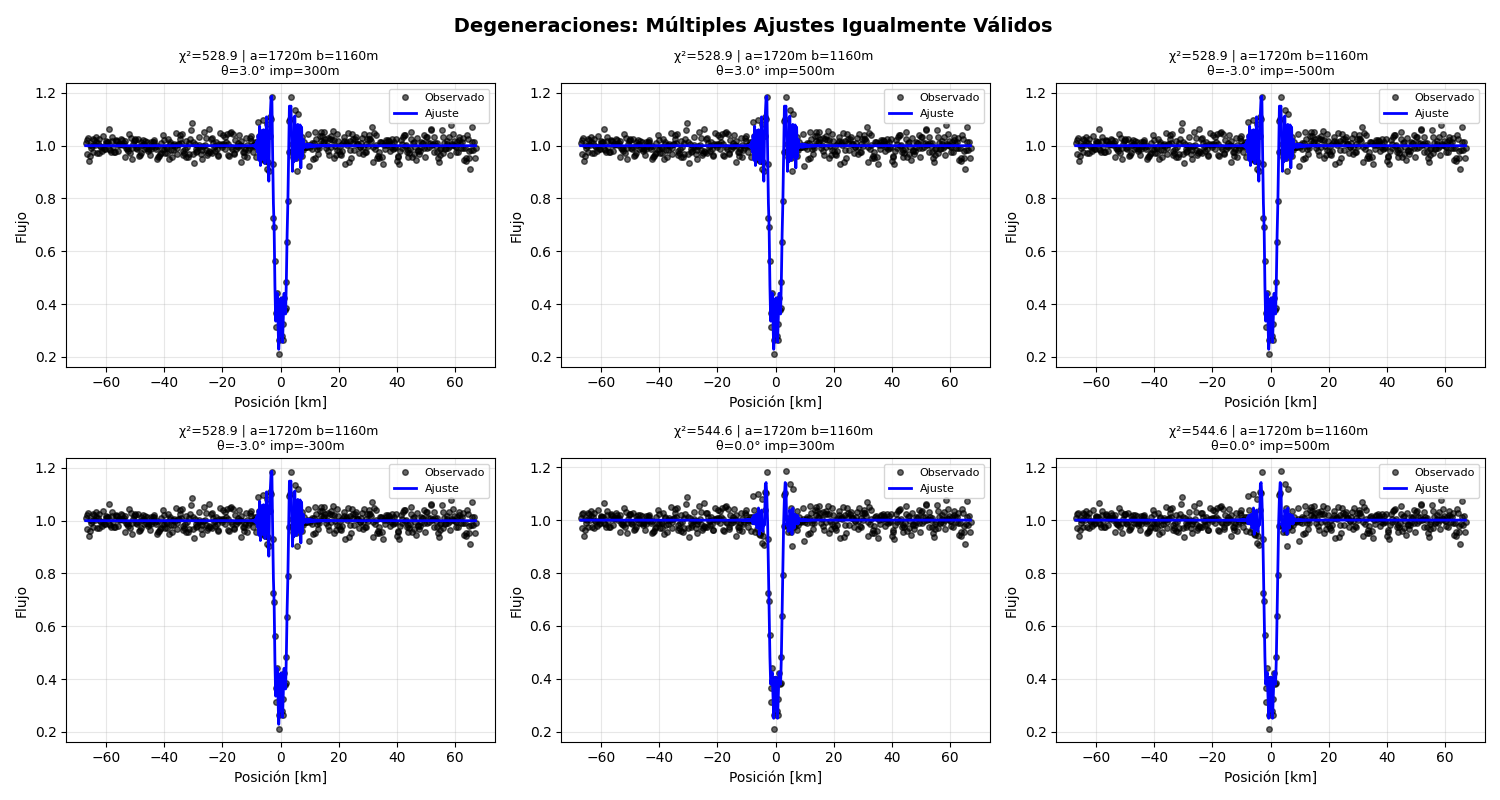

 Gráfico guardado en degeneraciones_comparacion.png


In [32]:
# Graficar top 6 degeneraciones
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(' Degeneraciones: Múltiples Ajustes Igualmente Válidos', 
             fontsize=14, fontweight='bold')

for idx, (ax, deg) in enumerate(zip(axes.flat, degeneraciones[:6])):
    ax.plot(x_ref/1000, y_obs, 'ko', label='Observado', markersize=4, alpha=0.6)
    ax.plot(x_ref/1000, deg['y_cal'], 'b-', label='Ajuste', linewidth=2)
    ax.set_xlabel('Posición [km]')
    ax.set_ylabel('Flujo')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    titulo = (f"χ²={deg['chi2']:.1f} | a={deg['a']:.0f}m b={deg['b']:.0f}m \n"
              f"θ={deg['theta']:.1f}° imp={deg['impacto']:.0f}m")
    ax.set_title(titulo, fontsize=9)

plt.tight_layout()
plt.savefig('degeneraciones_comparacion.png', dpi=150, bbox_inches='tight') 
plt.show()
print(" Gráfico guardado en degeneraciones_comparacion.png")

## 9️⃣ Espacio de Parámetros: Degeneraciones Visibles

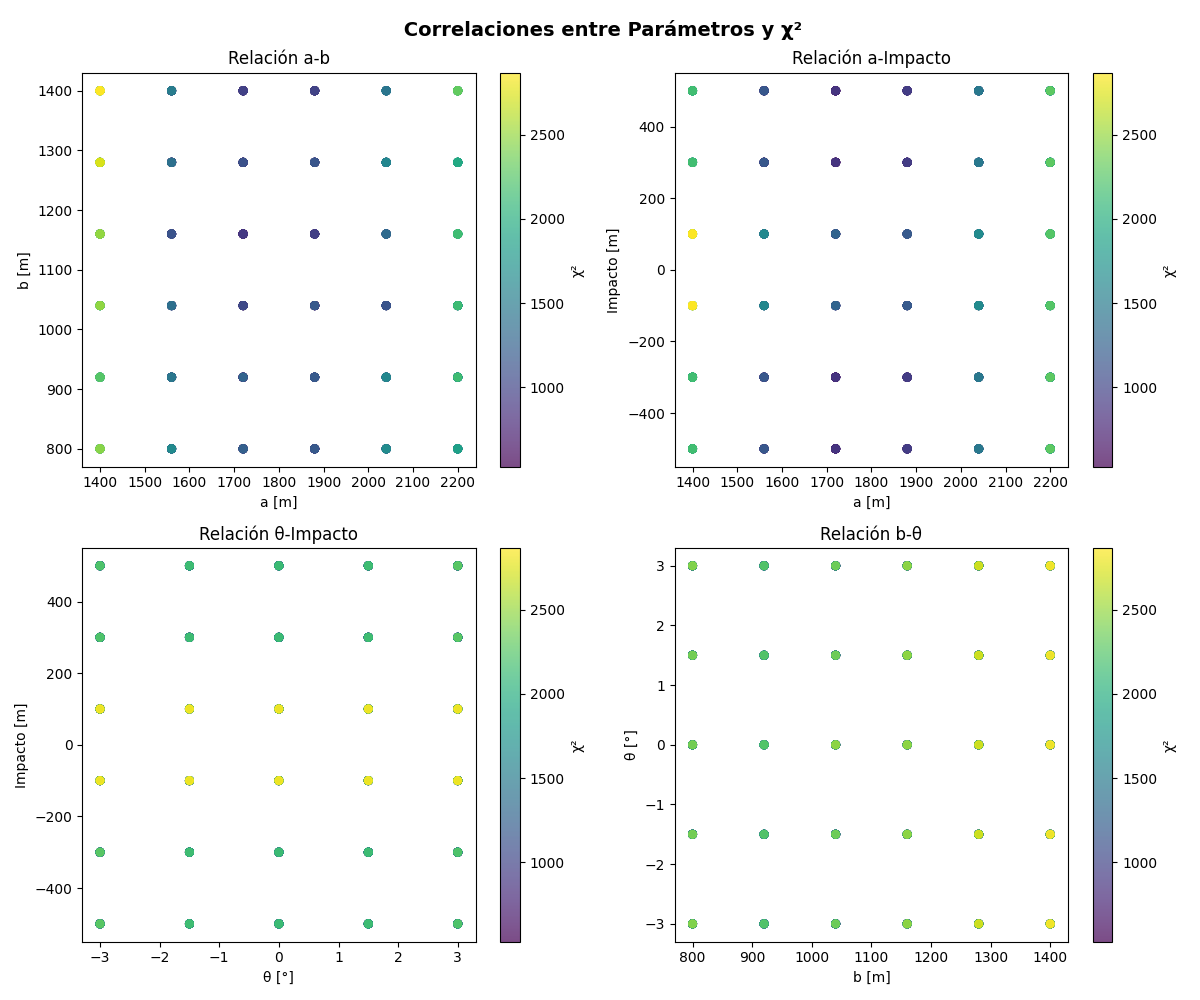

 Gráfico de espacio de parámetros guardado


In [33]:
# Convertir a arrays para ploteo
chi2_array = np.array([d['chi2'] for d in degeneraciones])
a_array = np.array([d['a'] for d in degeneraciones])
b_array = np.array([d['b'] for d in degeneraciones])
theta_array = np.array([d['theta'] for d in degeneraciones])
impacto_array = np.array([d['impacto'] for d in degeneraciones])

# Crear figura con subplots de correlaciones
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(' Correlaciones entre Parámetros y χ²', fontsize=14, fontweight='bold')

# a vs b (coloreado por chi2)
sc1 = axes[0, 0].scatter(a_array, b_array, c=chi2_array, cmap='viridis', s=30, alpha=0.7)
axes[0, 0].set_xlabel('a [m]')
axes[0, 0].set_ylabel('b [m]')
axes[0, 0].set_title('Relación a-b')
plt.colorbar(sc1, ax=axes[0, 0], label='χ²')

# a vs impacto
sc2 = axes[0, 1].scatter(a_array, impacto_array, c=chi2_array, cmap='viridis', s=30, alpha=0.7)
axes[0, 1].set_xlabel('a [m]')
axes[0, 1].set_ylabel('Impacto [m]')
axes[0, 1].set_title('Relación a-Impacto')
plt.colorbar(sc2, ax=axes[0, 1], label='χ²')

# theta vs impacto
sc3 = axes[1, 0].scatter(theta_array, impacto_array, c=chi2_array, cmap='viridis', s=30, alpha=0.7)
axes[1, 0].set_xlabel('θ [°]')
axes[1, 0].set_ylabel('Impacto [m]')
axes[1, 0].set_title('Relación θ-Impacto')
plt.colorbar(sc3, ax=axes[1, 0], label='χ²')

# b vs theta
sc4 = axes[1, 1].scatter(b_array, theta_array, c=chi2_array, cmap='viridis', s=30, alpha=0.7)
axes[1, 1].set_xlabel('b [m]')
axes[1, 1].set_ylabel('θ [°]')
axes[1, 1].set_title('Relación b-θ')
plt.colorbar(sc4, ax=axes[1, 1], label='χ²')

plt.tight_layout()
plt.savefig('espacio_parametros.png', dpi=150, bbox_inches='tight') 
plt.show()
print(" Gráfico de espacio de parámetros guardado")

## 🔟 Conclusiones sobre Degeneraciones

In [34]:
print("\n" + "="*80)
print("🎯 CONCLUSIONES SOBRE DEGENERACIONES")
print("="*80)

print("""
╔════════════════════════════════════════════════════════════════════════════╗
║                    PROBLEMA DE LA DEGENERACIÓN                             ║
╚════════════════════════════════════════════════════════════════════════════╝

✓ HALLAZGO CLAVE:
  Se encontraron múltiples conjuntos de parámetros (a, b, θ, impacto) que
  producen χ² similares, lo que significa que es IMPOSIBLE determinar 
  únicamente la forma, tamaño, orientación e impacto a partir de un único
  perfil de difracción.

✓ PATRONES OBSERVADOS:
  1. Cambios en 'a' y 'b' se compensan: aumentar 'a' se compensa con
     disminuir 'b' para mantener χ² bajo.
  
  2. Orientación e impacto son correlacionados: cambios en 'θ' pueden
     compensarse con cambios en 'impacto'.
  
  3. El espacio de parámetros forma "valles" degenerados donde múltiples
     soluciones son igualmente válidas.

✓ IMPLICACIONES ASTROFÍSICAS:
  - Un único evento de ocultación NO es suficiente para determinar
    unívocamente la forma del asteroide.
  - Se necesitan múltiples observaciones desde diferentes ángulos.
  - Los sistemas como TAOS-II funcionan porque registran múltiples
    estaciones (redundancia geográfica).

✓ SOLUCIONES:
  1. Usar múltiples observatorios (constraints adicionales)
  2. Modelar con información a priori (tamaño estimado, órbita, etc.)
  3. Combinar observaciones de múltiples eventos
  4. Usar métodos bayesianos con priors realistas

╔════════════════════════════════════════════════════════════════════════════╗
║                  ¡PROBLEMA INVERSO ILL-POSED!                             ║
╚════════════════════════════════════════════════════════════════════════════╝
""")

print(f"\n📊 Estadísticas de búsqueda:")
print(f"   Total de combinaciones exploradas: {len(degeneraciones)}")
print(f"   χ² mínimo encontrado: {degeneraciones[0]['chi2']:.2f}")
print(f"   Mejor χ²ᵣₑd: {degeneraciones[0]['chi2_red']:.4f}")
print(f"\n   Número de soluciones con χ² < 1.5×χ²_min: {sum(1 for d in degeneraciones if d['chi2'] < 1.5*degeneraciones[0]['chi2'])}")
print(f"   Número de soluciones con χ² < 2×χ²_min: {sum(1 for d in degeneraciones if d['chi2'] < 2*degeneraciones[0]['chi2'])}")


🎯 CONCLUSIONES SOBRE DEGENERACIONES

╔════════════════════════════════════════════════════════════════════════════╗
║                    PROBLEMA DE LA DEGENERACIÓN                             ║
╚════════════════════════════════════════════════════════════════════════════╝

✓ HALLAZGO CLAVE:
  Se encontraron múltiples conjuntos de parámetros (a, b, θ, impacto) que
  producen χ² similares, lo que significa que es IMPOSIBLE determinar 
  únicamente la forma, tamaño, orientación e impacto a partir de un único
  perfil de difracción.

✓ PATRONES OBSERVADOS:
  1. Cambios en 'a' y 'b' se compensan: aumentar 'a' se compensa con
     disminuir 'b' para mantener χ² bajo.

  2. Orientación e impacto son correlacionados: cambios en 'θ' pueden
     compensarse con cambios en 'impacto'.

  3. El espacio de parámetros forma "valles" degenerados donde múltiples
     soluciones son igualmente válidas.

✓ IMPLICACIONES ASTROFÍSICAS:
  - Un único evento de ocultación NO es suficiente para determinar
  

## Referencia

- **difraciones.py**: Librería original de Joel Castro (2019)
- **arranque.py**: Código de ejemplo y flujo principal
- **Este notebook**: Interfaz interactiva y análisis de degeneraciones

**Base matemática:** Difracción de Fresnel, FFT 2D, Extracción de perfiles 1D